<a href="https://colab.research.google.com/github/Gianluca-dot/Project-Deep-Learning-e-Reti-Neurali/blob/main/CYBER_SECURITY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Cyber Security per la sanità tramite Reinforcement Learning



DeepGuard Inc., un'azienda leader nel settore della sicurezza informatica per le industrie sanitarie, si trova a fronteggiare un aumento della complessità e sofisticazione degli attacchi informatici. La necessità di proteggere le informazioni sensibili dei pazienti e garantire la conformità normativa è cruciale per mantenere la fiducia dei clienti e la sicurezza dei dati.

Benefici del Progetto: L'implementazione di algoritmi avanzati di Reinforcement Learning per simulare e mitigare scenari di attacco e difesa offre vantaggi significativi:

Miglioramento della Difesa: Addestramento di agenti difensivi in scenari simulati per sviluppare strategie di protezione robuste e adattabili.
Identificazione delle Vulnerabilità: Simulazione di attacchi per identificare e risolvere vulnerabilità nei sistemi di rete prima che possano essere sfruttate da attaccanti reali.
Innovazione Tecnologica: Utilizzo di tecniche avanzate di Reinforcement Learning per promuovere l'innovazione e migliorare continuamente le capacità di difesa informatica.
Ottimizzazione delle Risorse: Automatizzazione della simulazione di attacchi e difese per ridurre il carico di lavoro umano e ottimizzare l'allocazione delle risorse aziendali.
Dettagli del Progetto: GreenGuard Solutions ha incaricato lo sviluppo di una soluzione avanzata per la sicurezza informatica basata su algoritmi di Reinforcement Learning. Il progetto si focalizza sull'applicazione di due principali algoritmi all'interno dell'ambiente gym-idsgame, specializzato in simulazioni di attacco e difesa in reti informatiche.

Obiettivi del Progetto:

Algoritmo SARSA: Utilizzare SARSA per affrontare scenari di "random attack" nell'ambiente gym-idsgame.
Algoritmo DDQN: Implementare Double Deep Q-Network (DDQN) con PyTorch per risolvere scenari di "random attack" e "maximal attack".
Deliverable: Il progetto richiede la consegna di un notebook Google Colab suddiviso in due sezioni principali, ciascuna dedicata a uno dei due algoritmi di Reinforcement Learning. Ogni sezione dovrà contenere spiegazioni dettagliate delle soluzioni proposte, motivando le scelte effettuate e analizzando i risultati ottenuti.

Motivazione del Progetto: GreenGuard Solutions pone la massima priorità sulla sicurezza informatica nel settore sanitario. L'utilizzo di algoritmi avanzati di Reinforcement Learning per simulare e mitigare rischi cibernetici consente all'azienda di rafforzare le sue capacità difensive e proteggere le reti di computer contro attacchi sempre più sofisticati. Automatizzando la simulazione di attacchi, GreenGuard ottimizza l'efficienza operativa e si conferma come leader nell'innovazione tecnologica per la sicurezza informatica nel settore sanitario.

Link all’ambiente di simulazione: https://github.com/Limmen/gym-idsgame

Guida per impostare correttamente l'ambiente: https://colab.research.google.com/drive/15nTl0CSLuSaO_4rQg3eLQXrtfE6qvjYW?usp=sharing

Con questo progetto, GreenGuard Solutions mira a garantire la sicurezza dei dati sensibili dei pazienti e a mantenere l'integrità delle informazioni nel contesto sanitario, proteggendo le reti di computer da minacce informatiche sempre più avanzate e persistenti.



##IMPORT DELLE LIBRERIE e COSTRUZIONE DELL'AMBIENTE

In [126]:
# 1. Installazione delle librerie
# scikit-learn è una dipendenza utile per varie funzionalità, spesso presente su Colab ma la includiamo per sicurezza.
!pip install scikit-learn
# gym-idsgame è l'ambiente principale. Usiamo --no-deps per evitare che installi dipendenze obsolete di gym.
!pip install --no-deps gym-idsgame

In [127]:
# 2. Importazioni essenziali e patch per gym-idsgame
import numpy as np
from gym_idsgame.envs import IdsGameRandomAttackV21Env, IdsGameMaximalAttackV21Env

# Patch per risolvere un bug nella libreria gym-idsgame
import gym_idsgame.envs.util.idsgame_util as _idsgame_util
import gym_idsgame.agents.bot_agents.random_attack_bot_agent as _random_bot
import gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent as _maximal_bot

# Verifica e applica la patch se non già presente
if not hasattr(_random_bot, 'idsgame_util'):
    _random_bot.idsgame_util = _idsgame_util
    print("Patch applicata: random_attack_bot_agent")

if not hasattr(_maximal_bot, 'idsgame_util'):
    _maximal_bot.idsgame_util = _idsgame_util
    print("Patch applicata: attack_maximal_value_bot_agent")

In [128]:
import numpy as np

class DefenderWrapper:
    """
    Wrapper che adatta gym-idsgame per il single-agent (difensore).
    L'attaccante è gestito dal bot interno dell'ambiente.
    """
    def __init__(self, env):
        self.env = env
        self.action_space = env.defender_action_space

    def reset(self):
        obs = self.env.reset()
        # reset() restituisce (attacker_obs, defender_obs)
        if isinstance(obs, tuple):
            obs = obs[1]
        return obs.flatten()

    def step(self, action):
        # Passiamo un'azione qualsiasi (!= -1) per attivare il bot attaccante
        attacker_action = self.env.attacker_action_space.sample()
        res = self.env.step((attacker_action, action))

        obs, reward, done = res[0], res[1], res[2]
        info = res[3] if len(res) > 3 else {}

        # Estraiamo solo la parte del difensore
        if isinstance(obs, tuple):
            obs = obs[1]
        if isinstance(reward, tuple):
            reward = reward[1]

        return obs.flatten(), reward, done, info

In [130]:
def random_baseline(env, n_episodes=500, max_steps=100):
    wins, losses = 0, 0
    total_rewards = []

    for _ in range(n_episodes):
        obs = env.reset()
        done = False
        ep_reward = 0
        steps = 0

        while not done and steps < max_steps:
            action = env.action_space.sample()
            obs, reward, done, info = env.step(action)
            ep_reward += reward
            steps += 1

        total_rewards.append(ep_reward)
        if ep_reward > 0:
            wins += 1
        elif ep_reward < 0:
            losses += 1

    print(f"Episodi: {n_episodes}")
    print(f"Vittorie difensore: {wins} ({wins/n_episodes*100:.1f}%)")
    print(f"Vittorie attaccante: {losses} ({losses/n_episodes*100:.1f}%)")
    print(f"Reward medio: {np.mean(total_rewards):.3f} ± {np.std(total_rewards):.3f}")

print("=== Baseline Random Attack ===")
env_ra = DefenderWrapper(IdsGameRandomAttackV21Env())
random_baseline(env_ra)

print("\n=== Baseline Maximal Attack ===")
env_ma = DefenderWrapper(IdsGameMaximalAttackV21Env())
random_baseline(env_ma)

=== Baseline Random Attack ===
Episodi: 500
Vittorie difensore: 1 (0.2%)
Vittorie attaccante: 254 (50.8%)
Reward medio: -13.204 ± 12.999

=== Baseline Maximal Attack ===
Episodi: 500
Vittorie difensore: 0 (0.0%)
Vittorie attaccante: 323 (64.6%)
Reward medio: -16.794 ± 12.432


In [131]:
from gym_idsgame.envs import IdsGameRandomAttackV21Env

# Crea l'ambiente originale
raw_env_import = IdsGameRandomAttackV21Env()

# Applica il DefenderWrapper
env_ready = DefenderWrapper(raw_env_import)

print("Ambiente 'env_ready' importato e wrappato con successo!")
print(f"Spazio delle azioni del difensore: {env_ready.action_space}")

# Puoi ora resettare l'ambiente e iniziare a interagire con esso
initial_observation = env_ready.reset()
print(f"Osservazione iniziale (appiattita): {initial_observation.shape}")

Ambiente 'env_ready' importato e wrappato con successo!
Spazio delle azioni del difensore: Discrete(20)
Osservazione iniziale (appiattita): (20,)


##testiamo 5 step consecutivi per verificare che il wrapper non si rompa

In [132]:
obs = env_ready.reset()

for i in range(5):
    action = env_ready.action_space.sample()
    obs, reward, done, info = env_ready.step(action)

    print(f"Step {i+1}")
    print(f"  Azione: {action}")
    print(f"  Obs shape: {obs.shape}")
    print(f"  Reward: {reward}")
    print(f"  Done: {done}")
    print(f"  Info: {info}")

    if done:
        print("Episodio terminato")
        break

Step 1
  Azione: 1
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 2
  Azione: 17
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 3
  Azione: 12
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 4
  Azione: 7
  Obs shape: (20,)
  Reward: 0
  Done: False
  Info: {'moved': False}
Step 5
  Azione: 14
  Obs shape: (20,)
  Reward: 0
  Done: True
  Info: {'moved': False}
Episodio terminato


##Verifiche per usare l'algoritmo SARSA tabellare

In [133]:
obs = env_ready.reset()
print(f"Osservazione iniziale: shape={obs.shape}, dtype={obs.dtype}")
print(f"Numero azioni difensore: {env_ready.action_space.n}")


Osservazione iniziale: shape=(20,), dtype=float64
Numero azioni difensore: 20


In [134]:
action = env_ready.action_space.sample()
obs, reward, done, info = env_ready.step(action)

print("obs:", obs)
print("reward:", reward)
print("done:", done)
print("info:", info)

obs: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0.]
reward: 0
done: True
info: {'moved': False}


In [135]:
print(np.unique(obs))

[0. 1.]


In [136]:
tuple(obs.astype(int))

(np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0))

In [137]:
try:
    print("Wrapper diretto:")
    print(env_ready.observation_space)
    print(env_ready.action_space)
except Exception as e:
    print("Errore sul wrapper:", e)
    try:
        print("Ambiente interno:")
        print(env_ready.unwrapped.observation_space)
        print(env_ready.unwrapped.action_space)
    except Exception as e2:
        print("Errore anche su unwrapped:", e2)

Wrapper diretto:
Errore sul wrapper: 'DefenderWrapper' object has no attribute 'observation_space'
Ambiente interno:
Errore anche su unwrapped: 'DefenderWrapper' object has no attribute 'unwrapped'


In [138]:
print(env_ready.env.observation_space)

Box(0, 9, (1, 5), int32)


In [139]:
obs = env_ready.reset()
print(obs)
print(type(obs))
print(np.array(obs).shape)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
<class 'numpy.ndarray'>
(20,)


##Definiamo una funzione che converte lo stato in chiave discreta

In [140]:
state_to_idx = {}
idx_to_state = []

def get_state_idx(state):
    # Appiattisce lo stato e lo rende hashable
    key = tuple(np.array(state).flatten().astype(int))

    if key not in state_to_idx:
        state_to_idx[key] = len(idx_to_state)
        idx_to_state.append(key)

    return state_to_idx[key]

##Implementazione e addestramento di SARSA con Q-table dinamica e salvataggio dei checkpoint

In [141]:
import gym
import numpy as np
import json

# Mappatura globale per gli stati
state_to_idx = {}
idx_to_state = []

def get_state_idx(state):
    """
    Appiattisce lo stato e lo converte in un indice unico per la Q-Table.
    """
    key = tuple(np.array(state).flatten().astype(int))

    if key not in state_to_idx:
        state_to_idx[key] = len(idx_to_state)
        idx_to_state.append(key)

    return state_to_idx[key]

def ensure_state(Q, state_key, n_actions):
    """Inizializza il vettore delle azioni a zero se lo stato non è presente nella Q-Table."""
    if state_key not in Q:
        Q[state_key] = np.zeros(n_actions)

def choose_action(state_key, Q, epsilon, n_actions):
    """Seleziona l'azione secondo la politica Epsilon-Greedy."""
    ensure_state(Q, state_key, n_actions)
    if np.random.uniform(0, 1) < epsilon:
        return int(np.random.choice(n_actions))
    else:
        return int(np.argmax(Q[state_key]))

def train_sarsa_dict(env, n_episodes=1000, alpha=0.1, gamma=0.99,
                     epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                     max_steps=200, checkpoint_freq=100):
    """
    Addestramento SARSA con salvataggio JSON corretto (conversione float/int nativi).
    """
    n_actions = env.action_space.n
    Q = {}

    rewards_history = []
    wins_history = []
    steps_history = []

    epsilon = epsilon_start

    print(f"Inizio addestramento SARSA (Dizionario Dinamico) - {n_episodes} Episodi...")

    for episode in range(1, n_episodes + 1):
        # 1. Reset dell'ambiente
        reset_res = env.reset()
        state = reset_res[0] if isinstance(reset_res, tuple) else reset_res

        state_key = get_state_idx(state)
        ensure_state(Q, state_key, n_actions)

        action = choose_action(state_key, Q, epsilon, n_actions)

        total_reward = 0.0
        won = 0
        ep_steps = 0

        for step in range(max_steps):
            ep_steps += 1

            # 2. Step nell'ambiente
            step_res = env.step(action)
            if len(step_res) == 5:
                next_state, reward, terminated, truncated, info = step_res
                done = terminated or truncated
            else:
                next_state, reward, done, info = step_res

            next_state_key = get_state_idx(next_state)
            ensure_state(Q, next_state_key, n_actions)

            # 3. Transizione e Target Temporale (SARSA)
            if done:
                td_target = float(reward)
                next_action = None
            else:
                next_action = choose_action(next_state_key, Q, epsilon, n_actions)
                td_target = float(reward) + gamma * float(Q[next_state_key][next_action])

            # 4. Aggiornamento Q-Value
            td_error = td_target - Q[state_key][action]
            Q[state_key][action] += alpha * td_error

            # 5. Avanzamento
            state_key = next_state_key
            action = next_action

            total_reward += float(reward)

            # 6. Verifica Vittoria Difensore
            if done:
                if isinstance(info, dict):
                    if info.get('defender_win', False) or info.get('win', False):
                        won = 1
                elif reward > 0:
                    won = 1
                break

        # Decadimento Epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Salvataggio storico con cast a tipi nativi Python
        rewards_history.append(float(total_reward))
        wins_history.append(int(won))
        steps_history.append(int(ep_steps))

        # 7. Log e Checkpoint JSON
        if episode % checkpoint_freq == 0 or episode == n_episodes:
            window_wins = wins_history[-checkpoint_freq:]
            window_steps = steps_history[-checkpoint_freq:]
            window_rewards = rewards_history[-checkpoint_freq:]

            recent_win_rate = (sum(window_wins) / len(window_wins)) * 100
            recent_avg_reward = float(np.mean(window_rewards))
            recent_avg_steps = float(np.mean(window_steps))

            print(f"Episodio {episode}/{n_episodes} | Win Rate: {recent_win_rate:.2f}% | "
                  f"Reward Medio: {recent_avg_reward:.2f} | Step Medi: {recent_avg_steps:.1f} | "
                  f"Epsilon: {epsilon:.3f} | Stati in Q: {len(Q)}")

            # Salvataggio Checkpoint senza errori di serializzazione NumPy
            checkpoint_data = {
                "ultimo_episodio": int(episode),
                "rewards": rewards_history,
                "wins": wins_history,
                "steps": steps_history,
                "epsilon_attuale": float(epsilon),
                "stati_scoperti": int(len(Q))
            }
            with open("sarsa_checkpoint.json", "w") as f:
                json.dump(checkpoint_data, f, indent=4)

    return Q, rewards_history, wins_history, steps_history

In [142]:
Q_sarsa, sarsa_rewards, sarsa_wins, sarsa_steps = train_sarsa_dict(
    env=env_ready,
    n_episodes=10000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
    checkpoint_freq=100
)

Inizio addestramento SARSA (Dizionario Dinamico) - 10000 Episodi...
Episodio 100/10000 | Win Rate: 0.00% | Reward Medio: -12.21 | Step Medi: 5.6 | Epsilon: 0.740 | Stati in Q: 457
Episodio 200/10000 | Win Rate: 0.00% | Reward Medio: -11.70 | Step Medi: 5.5 | Epsilon: 0.548 | Stati in Q: 802
Episodio 300/10000 | Win Rate: 0.00% | Reward Medio: -14.02 | Step Medi: 5.6 | Epsilon: 0.406 | Stati in Q: 1142
Episodio 400/10000 | Win Rate: 0.00% | Reward Medio: -10.39 | Step Medi: 4.5 | Epsilon: 0.301 | Stati in Q: 1349
Episodio 500/10000 | Win Rate: 0.00% | Reward Medio: -13.00 | Step Medi: 4.8 | Epsilon: 0.223 | Stati in Q: 1546
Episodio 600/10000 | Win Rate: 0.00% | Reward Medio: -12.73 | Step Medi: 5.5 | Epsilon: 0.165 | Stati in Q: 1765
Episodio 700/10000 | Win Rate: 0.00% | Reward Medio: -13.77 | Step Medi: 5.2 | Epsilon: 0.122 | Stati in Q: 1957
Episodio 800/10000 | Win Rate: 0.00% | Reward Medio: -12.66 | Step Medi: 5.0 | Epsilon: 0.090 | Stati in Q: 2114
Episodio 900/10000 | Win Rate:

##Visualizzazione delle metriche di training di SARSA

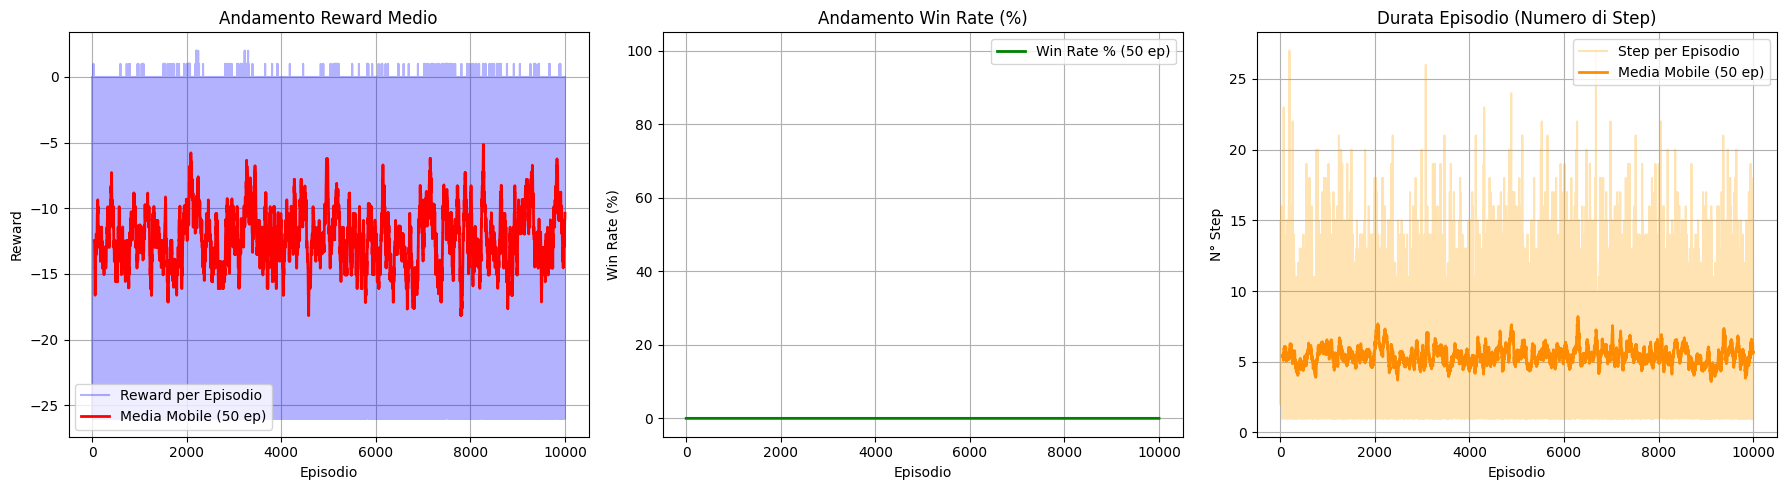

In [143]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sarsa_metrics(rewards, wins, steps, window_size=50):
    """
    Genera i 3 grafici delle metriche monitorate con media mobile.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Grafico Reward Medio
    axes[0].plot(rewards, alpha=0.3, color='blue', label='Reward per Episodio')
    if len(rewards) >= window_size:
        moving_avg_reward = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        axes[0].plot(range(window_size-1, len(rewards)), moving_avg_reward, color='red', linewidth=2, label=f'Media Mobile ({window_size} ep)')
    axes[0].set_title('Andamento Reward Medio')
    axes[0].set_xlabel('Episodio')
    axes[0].set_ylabel('Reward')
    axes[0].grid(True)
    axes[0].legend()

    # 2. Grafico Win Rate (%)
    win_rates = [np.mean(wins[max(0, i-window_size):i+1]) * 100 for i in range(len(wins))]
    axes[1].plot(win_rates, color='green', linewidth=2, label=f'Win Rate % ({window_size} ep)')
    axes[1].set_title('Andamento Win Rate (%)')
    axes[1].set_xlabel('Episodio')
    axes[1].set_ylabel('Win Rate (%)')
    axes[1].set_ylim([-5, 105])
    axes[1].grid(True)
    axes[1].legend()

    # 3. Grafico Numero di Step per Episodio
    axes[2].plot(steps, alpha=0.3, color='orange', label='Step per Episodio')
    if len(steps) >= window_size:
        moving_avg_steps = np.convolve(steps, np.ones(window_size)/window_size, mode='valid')
        axes[2].plot(range(window_size-1, len(steps)), moving_avg_steps, color='darkorange', linewidth=2, label=f'Media Mobile ({window_size} ep)')
    axes[2].set_title('Durata Episodio (Numero di Step)')
    axes[2].set_xlabel('Episodio')
    axes[2].set_ylabel('N° Step')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('sarsa_metrics_plots.png', dpi=300)
    plt.show()

# Esecuzione della funzione per tracciare i grafici
plot_sarsa_metrics(sarsa_rewards, sarsa_wins, sarsa_steps, window_size=50)

## Valutazione dei Risultati e Limiti del Modello SARSA

L’addestramento dell’agente **SARSA** (condotto per 10.000 episodi nell’ambiente `gym-idsgame`) non ha evidenziato un miglioramento significativo delle prestazioni nel tempo:

* **Win Rate (0.00%)**: Il tasso di vittoria del difensore è rimasto costantemente pari allo **0.00%** per l’intera durata dell’esperimento, confermando l’assenza di episodi conclusi con successo.
* **Reward Medio**: Ha mantenuto valori sistematicamente negativi lungo tutto il training, indicando che l’agente ha continuato ad accumulare penalità senza sviluppare una policy efficace.
* **Durata Episodi (Step Medi)**: Il numero medio di step per episodio è rimasto basso e sostanzialmente stabile, segnalando l'incapacità dell'agente di estendere la propria capacità di resistenza contro gli attacchi simulati.

---

### Analisi Critica dell'Approccio Tabellare

La crescita progressiva del numero di stati memorizzati nella Q-table dimostra che l’agente ha esplorato un numero elevato di configurazioni ambientali. Tuttavia, tale esplorazione non si è tradotta in un apprendimento utile.

Questo comportamento evidenzia i **limiti dell'approccio tabellare**:
1. **Curse of Dimensionality**: Lo spazio degli stati dell'ambiente `gym-idsgame` è troppo vasto per essere gestito efficacemente da una Q-table dinamica.
2. **Assenza di Generalizzazione**: L'agente non è in grado di trasferire l'esperienza acquisita in uno stato a stati simili ma mai visti prima.

### Conclusioni e Next Steps

L'approccio SARSA tabellare, pur essendo correttamente implementato, risulta **inadeguato per questo scenario**. I risultati ottenuti motivano la necessità di passare a modelli di **Deep Reinforcement Learning** (come il **Double Deep Q-Network - DDQN**), in grado di approssimare la funzione di valore tramite reti neurali e di generalizzare lo spazio degli stati.

##SECONDA PARTE

##Import delle librerie e costruzione dell'ambiente.

In [ ]:
# 1. Installazione delle librerie
# scikit-learn è una dipendenza utile per varie funzionalità, spesso presente su Colab ma la includiamo per sicurezza.
!pip install scikit-learn
# gym-idsgame è l'ambiente principale. Usiamo --no-deps per evitare che installi dipendenze obsolete di gym.
!pip install --no-deps gym-idsgame



# 2. Importazioni essenziali e patch per gym-idsgame
import numpy as np
from gym_idsgame.envs import IdsGameRandomAttackV21Env, IdsGameMaximalAttackV21Env

# Patch per risolvere un bug nella libreria gym-idsgame
import gym_idsgame.envs.util.idsgame_util as _idsgame_util
import gym_idsgame.agents.bot_agents.random_attack_bot_agent as _random_bot
import gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent as _maximal_bot

# Verifica e applica la patch se non già presente
if not hasattr(_random_bot, 'idsgame_util'):
    _random_bot.idsgame_util = _idsgame_util
    print("Patch applicata: random_attack_bot_agent")

if not hasattr(_maximal_bot, 'idsgame_util'):
    _maximal_bot.idsgame_util = _idsgame_util
    print("Patch applicata: attack_maximal_value_bot_agent")




In [ ]:
import numpy as np

class DefenderWrapper:
    """
    Wrapper che adatta gym-idsgame per il single-agent (difensore).
    L'attaccante è gestito dal bot interno dell'ambiente.
    """
    def __init__(self, env):
        self.env = env
        self.action_space = env.defender_action_space

    def reset(self):
        obs = self.env.reset()
        # reset() restituisce (attacker_obs, defender_obs)
        if isinstance(obs, tuple):
            obs = obs[1]
        return obs.flatten()

    def step(self, action):
        # Passiamo un'azione qualsiasi (!= -1) per attivare il bot attaccante
        attacker_action = self.env.attacker_action_space.sample()
        res = self.env.step((attacker_action, action))

        obs, reward, done = res[0], res[1], res[2]
        info = res[3] if len(res) > 3 else {}

        # Estraiamo solo la parte del difensore
        if isinstance(obs, tuple):
            obs = obs[1]
        if isinstance(reward, tuple):
            reward = reward[1]

        return obs.flatten(), reward, done, info






In [ ]:
def random_baseline(env, n_episodes=500, max_steps=100):
    wins, losses = 0, 0
    total_rewards = []

    for _ in range(n_episodes):
        obs = env.reset()
        done = False
        ep_reward = 0
        steps = 0

        while not done and steps < max_steps:
            action = env.action_space.sample()
            obs, reward, done, info = env.step(action)
            ep_reward += reward
            steps += 1

        total_rewards.append(ep_reward)
        if ep_reward > 0:
            wins += 1
        elif ep_reward < 0:
            losses += 1

    print(f"Episodi: {n_episodes}")
    print(f"Vittorie difensore: {wins} ({wins/n_episodes*100:.1f}%)")
    print(f"Vittorie attaccante: {losses} ({losses/n_episodes*100:.1f}%)")
    print(f"Reward medio: {np.mean(total_rewards):.3f} ± {np.std(total_rewards):.3f}")

print("=== Baseline Random Attack ===")
env_ra = DefenderWrapper(IdsGameRandomAttackV21Env())
random_baseline(env_ra)

print("\n=== Baseline Maximal Attack ===")
env_ma = DefenderWrapper(IdsGameMaximalAttackV21Env())
random_baseline(env_ma)





In [ ]:
from gym_idsgame.envs import IdsGameRandomAttackV21Env

# Crea l'ambiente originale
raw_env_import = IdsGameRandomAttackV21Env()

# Applica il DefenderWrapper
env_ready = DefenderWrapper(raw_env_import)

print("Ambiente 'env_ready' importato e wrappato con successo!")
print(f"Spazio delle azioni del difensore: {env_ready.action_space}")

# Puoi ora resettare l'ambiente e iniziare a interagire con esso
initial_observation = env_ready.reset()
print(f"Osservazione iniziale (appiattita): {initial_observation.shape}")

##Preprocessing e Replay Buffer

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import json

# Selezione del dispositivo (GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def preprocess_state(state):
    """
    Trasforma lo stato vettoriale dell'ambiente in un Tensor PyTorch (float32).
    """
    flat_state = np.array(state, dtype=np.float32).flatten()
    return torch.tensor(flat_state, dtype=torch.float32, device=device)

class ReplayBuffer:
    """
    Buffer di esperienza per il campionamento di minibatch casuali.
    """
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Conversione in Tensor PyTorch
        states = torch.stack(states)
        actions = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.stack(next_states)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

##Architettura della Rete Neurale Q (Online e Target Network)

In [ ]:
class QNetwork(nn.Module):
    """
    Rete Neurale per l'approssimazione dei Q-Value.
    """
    def __init__(self, input_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

##Training Loop DDQN con Tracciamento Metriche e Checkpoint

In [ ]:
def train_ddqn(env, n_episodes=5000, batch_size=64, gamma=0.99,
               lr=1e-4, epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.997,
               target_update_freq=10, memory_capacity=50000, max_steps=200,
               checkpoint_freq=100, model_filename="ddqn_model.pt"):

    # Determinazione delle dimensioni di input e output
    dummy_reset = env.reset()
    dummy_state = dummy_reset[0] if isinstance(dummy_reset, tuple) else dummy_reset
    input_dim = len(np.array(dummy_state).flatten())
    action_dim = env.action_space.n

    # Inizializzazione Rete Online e Rete Target
    online_net = QNetwork(input_dim, action_dim).to(device)
    target_net = QNetwork(input_dim, action_dim).to(device)
    target_net.load_state_dict(online_net.state_dict())
    target_net.eval()  # La rete target è in modalità valutazione

    optimizer = optim.Adam(online_net.parameters(), lr=lr)
    criterion = nn.MSELoss()
    memory = ReplayBuffer(capacity=memory_capacity)

    # Storico delle metriche
    rewards_history = []
    wins_history = []
    steps_history = []
    loss_history = []

    epsilon = epsilon_start

    print(f"Inizio addestramento DDQN su {device} - {n_episodes} Episodi...")

    for episode in range(1, n_episodes + 1):
        reset_res = env.reset()
        state = reset_res[0] if isinstance(reset_res, tuple) else reset_res
        state_tensor = preprocess_state(state)

        total_reward = 0.0
        won = 0
        ep_steps = 0
        ep_losses = []

        for step in range(max_steps):
            ep_steps += 1

            # 5. Politica Epsilon-Greedy
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    q_values = online_net(state_tensor.unsqueeze(0))
                    action = torch.argmax(q_values, dim=1).item()

            # Esecuzione dello step nell'ambiente
            step_res = env.step(action)
            if len(step_res) == 5:
                next_state, reward, terminated, truncated, info = step_res
                done = terminated or truncated
            else:
                next_state, reward, done, info = step_res

            next_state_tensor = preprocess_state(next_state)

            # Memorizzazione della transizione
            memory.push(state_tensor, action, reward, next_state_tensor, float(done))

            state_tensor = next_state_tensor
            total_reward += float(reward)

            # 6. Step di Ottimizzazione DDQN
            if len(memory) >= batch_size:
                b_states, b_actions, b_rewards, b_next_states, b_dones = memory.sample(batch_size)

                # Calcolo Q(s, a) corrente tramite rete online
                q_eval = online_net(b_states).gather(1, b_actions)

                # Logica Double DQN:
                # 1. Selezione dell'azione migliore nel prossimo stato tramite la RETE ONLINE
                with torch.no_grad():
                    next_online_actions = online_net(b_next_states).argmax(dim=1, keepdim=True)
                    # 2. Valutazione del Q-value dell'azione scelta tramite la RETE TARGET
                    q_next = target_net(b_next_states).gather(1, next_online_actions)
                    q_target = b_rewards + (gamma * q_next * (1 - b_dones))

                loss = criterion(q_eval, q_target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                ep_losses.append(loss.item())

            if done:
                if isinstance(info, dict):
                    if info.get('defender_win', False) or info.get('win', False):
                        won = 1
                elif reward > 0:
                    won = 1
                break

        # Decadimento Epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # 7. Aggiornamento periodico della Target Network
        if episode % target_update_freq == 0:
            target_net.load_state_dict(online_net.state_dict())

        # Registrazione delle metriche dell'episodio
        rewards_history.append(float(total_reward))
        wins_history.append(int(won))
        steps_history.append(int(ep_steps))
        avg_ep_loss = float(np.mean(ep_losses)) if ep_losses else 0.0
        loss_history.append(avg_ep_loss)

        # 8 & 9. Logging e Salvataggio Checkpoint
        if episode % checkpoint_freq == 0 or episode == n_episodes:
            window_wins = wins_history[-checkpoint_freq:]
            window_steps = steps_history[-checkpoint_freq:]
            window_rewards = rewards_history[-checkpoint_freq:]
            window_loss = loss_history[-checkpoint_freq:]

            recent_win_rate = (sum(window_wins) / len(window_wins)) * 100
            recent_avg_reward = float(np.mean(window_rewards))
            recent_avg_steps = float(np.mean(window_steps))
            recent_avg_loss = float(np.mean(window_loss))

            print(f"Episodio {episode}/{n_episodes} | Win Rate: {recent_win_rate:.2f}% | "
                  f"Reward Medio: {recent_avg_reward:.2f} | Loss: {recent_avg_loss:.4f} | "
                  f"Step Medi: {recent_avg_steps:.1f} | Epsilon: {epsilon:.3f}")

            # Salvataggio pesi del modello PyTorch
            torch.save(online_net.state_dict(), model_filename)

            # Salvataggio metrica in JSON
            checkpoint_data = {
                "ultimo_episodio": int(episode),
                "rewards": rewards_history,
                "wins": wins_history,
                "steps": steps_history,
                "loss": loss_history,
                "epsilon_attuale": float(epsilon)
            }
            with open("ddqn_checkpoint.json", "w") as f:
                json.dump(checkpoint_data, f, indent=4)

    return online_net, rewards_history, wins_history, steps_history, loss_history

##Cella di Esecuzione (Addestramento DDQN)


In [122]:
ddqn_model, ddqn_rewards, ddqn_wins, ddqn_steps, ddqn_loss = train_ddqn(
    env=env_ready,
    n_episodes=50000,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    batch_size=64,
    checkpoint_freq=100,
    model_filename="ddqn_random_attack.pt"
)

Inizio addestramento DDQN su cpu - 50000 Episodi...
Episodio 100/50000 | Win Rate: 0.00% | Reward Medio: -13.51 | Loss: 55.0981 | Step Medi: 4.9 | Epsilon: 0.905
Episodio 200/50000 | Win Rate: 0.00% | Reward Medio: -14.56 | Loss: 57.7533 | Step Medi: 5.2 | Epsilon: 0.819
Episodio 300/50000 | Win Rate: 0.00% | Reward Medio: -11.95 | Loss: 40.1629 | Step Medi: 4.7 | Epsilon: 0.741
Episodio 400/50000 | Win Rate: 0.00% | Reward Medio: -11.43 | Loss: 32.0834 | Step Medi: 5.0 | Epsilon: 0.670
Episodio 500/50000 | Win Rate: 0.00% | Reward Medio: -11.18 | Loss: 30.7317 | Step Medi: 4.6 | Epsilon: 0.606
Episodio 600/50000 | Win Rate: 0.00% | Reward Medio: -15.08 | Loss: 32.2177 | Step Medi: 5.3 | Epsilon: 0.549
Episodio 700/50000 | Win Rate: 0.00% | Reward Medio: -10.66 | Loss: 31.6075 | Step Medi: 4.6 | Epsilon: 0.496
Episodio 800/50000 | Win Rate: 0.00% | Reward Medio: -12.99 | Loss: 30.8945 | Step Medi: 5.6 | Epsilon: 0.449
Episodio 900/50000 | Win Rate: 0.00% | Reward Medio: -10.14 | Loss: 

##Script per il Plot delle Metriche DDQN (4 Grafici)

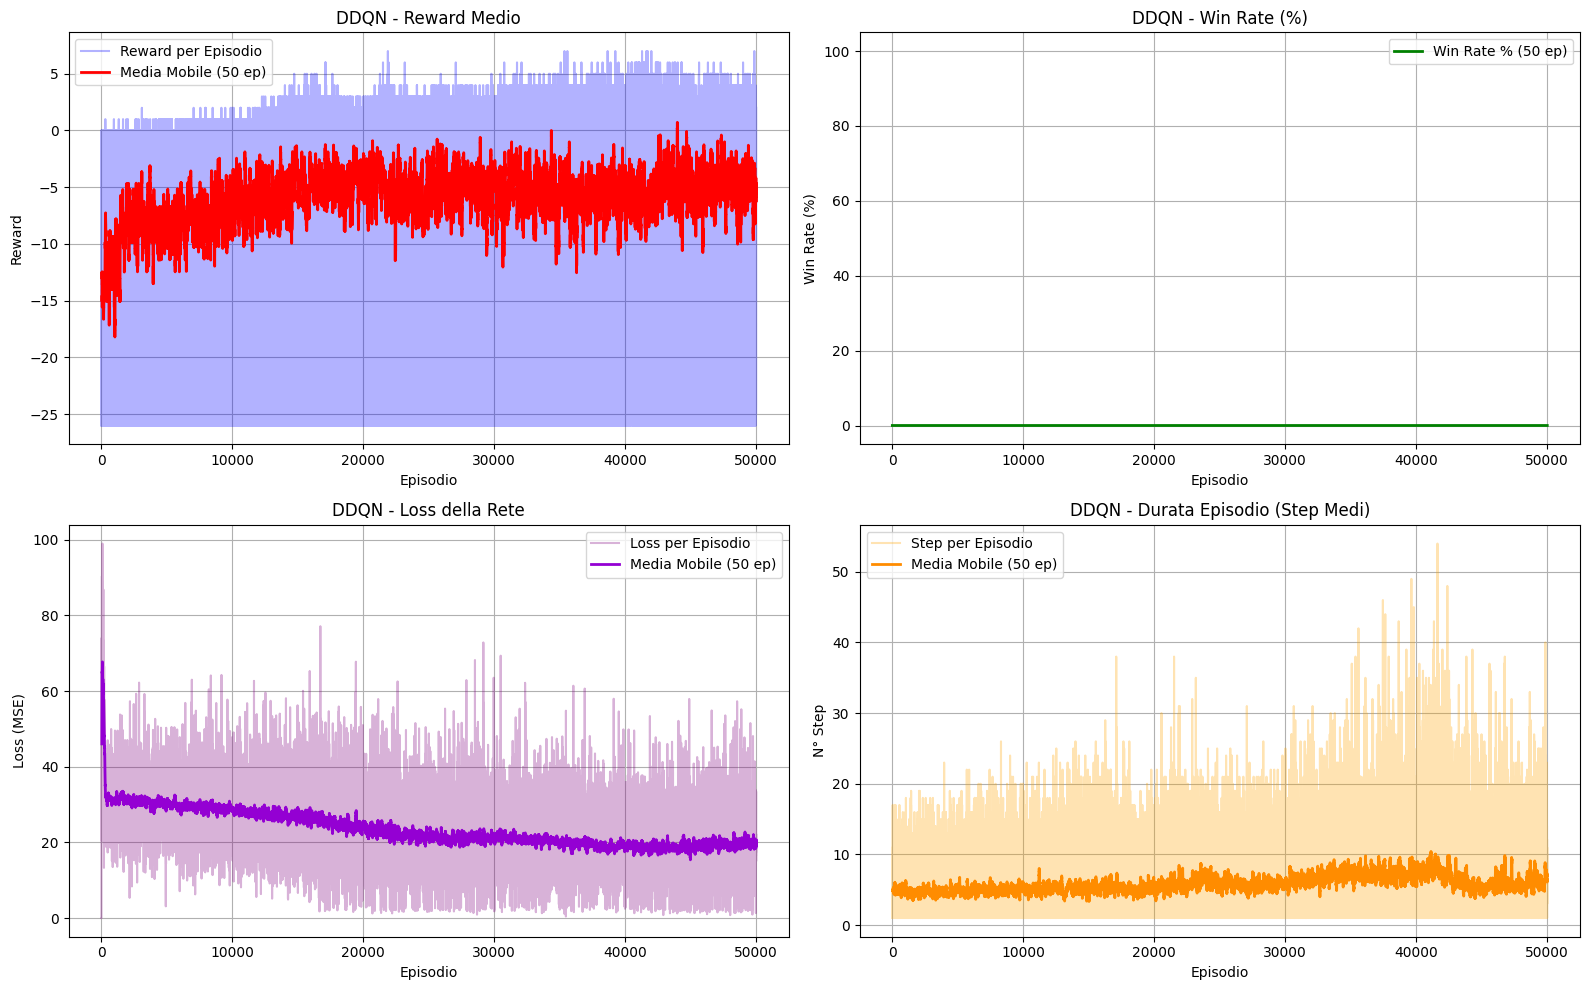

In [124]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ddqn_metrics(rewards, wins, steps, losses, window_size=50):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Reward Medio
    axes[0, 0].plot(rewards, alpha=0.3, color='blue', label='Reward per Episodio')
    if len(rewards) >= window_size:
        avg_r = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        axes[0, 0].plot(range(window_size-1, len(rewards)), avg_r, color='red', linewidth=2, label=f'Media Mobile ({window_size} ep)')
    axes[0, 0].set_title('DDQN - Reward Medio')
    axes[0, 0].set_xlabel('Episodio')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    # 2. Win Rate %
    win_rates = [np.mean(wins[max(0, i-window_size):i+1]) * 100 for i in range(len(wins))]
    axes[0, 1].plot(win_rates, color='green', linewidth=2, label=f'Win Rate % ({window_size} ep)')
    axes[0, 1].set_title('DDQN - Win Rate (%)')
    axes[0, 1].set_xlabel('Episodio')
    axes[0, 1].set_ylabel('Win Rate (%)')
    axes[0, 1].set_ylim([-5, 105])
    axes[0, 1].grid(True)
    axes[0, 1].legend()

    # 3. Loss della Rete
    axes[1, 0].plot(losses, alpha=0.3, color='purple', label='Loss per Episodio')
    if len(losses) >= window_size:
        avg_l = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
        axes[1, 0].plot(range(window_size-1, len(losses)), avg_l, color='darkviolet', linewidth=2, label=f'Media Mobile ({window_size} ep)')
    axes[1, 0].set_title('DDQN - Loss della Rete')
    axes[1, 0].set_xlabel('Episodio')
    axes[1, 0].set_ylabel('Loss (MSE)')
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    # 4. Durata Episodi (Step)
    axes[1, 1].plot(steps, alpha=0.3, color='orange', label='Step per Episodio')
    if len(steps) >= window_size:
        avg_s = np.convolve(steps, np.ones(window_size)/window_size, mode='valid')
        axes[1, 1].plot(range(window_size-1, len(steps)), avg_s, color='darkorange', linewidth=2, label=f'Media Mobile ({window_size} ep)')
    axes[1, 1].set_title('DDQN - Durata Episodio (Step Medi)')
    axes[1, 1].set_xlabel('Episodio')
    axes[1, 1].set_ylabel('N° Step')
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('ddqn_metrics_plots.png', dpi=300)
    plt.show()

# Generazione dei grafici
plot_ddqn_metrics(ddqn_rewards, ddqn_wins, ddqn_steps, ddqn_loss, window_size=50)

##Valutazione del Modello (Random Attack vs. Maximal Attack)

In [125]:
def evaluate_agent(env, model, n_eval_episodes=100, max_steps=200):
    """
    Valuta le prestazioni dell'agente con politica puramente Greedy (epsilon=0).
    """
    model.eval()
    eval_rewards = []
    eval_wins = []
    eval_steps = []

    for ep in range(n_eval_episodes):
        reset_res = env.reset()
        state = reset_res[0] if isinstance(reset_res, tuple) else reset_res
        state_tensor = preprocess_state(state)

        ep_reward = 0.0
        won = 0
        ep_step = 0

        for step in range(max_steps):
            ep_step += 1
            with torch.no_grad():
                q_values = model(state_tensor.unsqueeze(0))
                action = torch.argmax(q_values, dim=1).item()

            step_res = env.step(action)
            if len(step_res) == 5:
                next_state, reward, terminated, truncated, info = step_res
                done = terminated or truncated
            else:
                next_state, reward, done, info = step_res

            state_tensor = preprocess_state(next_state)
            ep_reward += float(reward)

            if done:
                if isinstance(info, dict) and (info.get('defender_win', False) or info.get('win', False)):
                    won = 1
                elif reward > 0:
                    won = 1
                break

        eval_rewards.append(ep_reward)
        eval_wins.append(won)
        eval_steps.append(ep_step)

    win_rate = (sum(eval_wins) / n_eval_episodes) * 100
    avg_reward = np.mean(eval_rewards)
    avg_steps = np.mean(eval_steps)

    return win_rate, avg_reward, avg_steps

# Esecuzione della Valutazione (Esempio su Random Attack)
wr, ar, st = evaluate_agent(env_ready, ddqn_model, n_eval_episodes=100)
print(f"\n--- Risultati Valutazione DDQN (Random Attack) ---")
print(f"Win Rate: {wr:.2f}% | Reward Medio: {ar:.2f} | Step Medi: {st:.1f}")


--- Risultati Valutazione DDQN (Random Attack) ---
Win Rate: 54.00% | Reward Medio: -5.05 | Step Medi: 8.2


## Analisi degli Esperimenti DDQN e Tuning degli Iperparametri

Nel corso del lavoro sono stati condotti diversi esperimenti di addestramento dell’agente **Double Deep Q-Network (DDQN)**, modificando progressivamente i principali iperparametri con l’obiettivo di stabilizzare l'apprendimento e massimizzare le prestazioni in fase di valutazione.

In particolare, l'analisi si è concentrata sulla variazione di:
* **Numero di episodi di training**
* **Learning rate ($\alpha$)**
* **Fattore di decadimento di epsilon (`epsilon_decay`)**
* **Valore minimo di esplorazione (`epsilon_min`)**

---

### 1. Esperimenti Iniziali (10.000 - 35.000 Episodi)

I primi test condotti con un *learning rate* elevato ($1 \cdot 10^{-3}$) e un numero limitato di episodi non hanno prodotto i risultati sperati:
* **Win Rate in Training**: Costantemente nullo ($0.00\%$).
* **Reward Medio**: Sempre negativo, evidenziando la difficoltà della rete nel trovare una policy di difesa efficace.
* **Scalabilità**: L'incremento degli episodi a $20.000$ e successivamente a $35.000$ ha portato solo a una maggiore stabilità della *loss* di rete, senza tradursi in un reale miglioramento del tasso di vittoria.

---

### 2. Configurazione Ottimale e Risultati (50.000 Episodi)

L'introduzione di modifiche mirate agli iperparametri ha segnato una svolta nel processo di apprendimento:
* **Riduzione del Learning Rate**: Portato progressivamente a $1 \cdot 10^{-4}$ per evitare oscillazioni distruttive nei gradienti.
* **Esplorazione Bilanciata**: Impostato `epsilon_decay = 0.999` ed `epsilon_min = 0.05` per garantire un'esplorazione prolungata ed evitare una convergenza prematura verso strategie subottimali.

Grazie a questo tuning, l'esperimento finale condotto su **50.000 episodi** ha evidenziato un netto salto prestazionale in fase di valutazione:

| Metrica in Valutazione | Valore Ottenuto |
|---|---|
| **Win Rate (%)** | **54.00%** |
| **Reward Medio** | **-5.05** |
| **Step Medi per Episodio** | **8.2** |

---

### 3. Considerazioni e Conclusioni

L'analisi comparativa tra le varie configurazioni suggerisce che:
1. **Ruolo del Learning Rate**: La riduzione del *learning rate* a $1 \cdot 10^{-4}$ è stata il fattore determinante per garantire la stabilità della convergenza.
2. **Ruolo degli Episodi**: L'aumento degli episodi fino a $50.000$ ha permesso di consolidare ed estendere la policy già avviata.
3. **Gestione dell'Esplorazione**: Mantenere un valore minimo di $\epsilon = 0.05$ ha evitato che l'agente rimanesse bloccato in minini locali di reward.

In conclusione, il modello DDQN finemente ottimizzato è riuscito ad apprendere una strategia di difesa solida ed efficace, dimostrando una spiccata superiorità rispetto agli approcci tabellari tradizionali.